# Brazil in the FIFA World Cup Analysis - Victor De Oliveira

As the FIFA World Cup approaches, I want to take a closer look at what to expect from my country in terms of performance and statistics. Using data from the ISLP package along with web-scraped information from Wikipedia, we’ll focus on analyzing Brazil’s historical performance in the tournament using real-world data.


In [7]:

!pip install ISLP pandas matplotlib beautifulsoup4 lxml requests --quiet
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
from ISLP import load_data


In [11]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/Brazil_at_the_FIFA_World_Cup"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

print("Tables found:", len(tables))

brazil_wc = tables[0]
display(brazil_wc.head())

Tables found: 35


/tmp/ipykernel_24039/1656099135.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Year,Round,Position,Pld,W,D*,L,GF,GA
0,1930,Group stage,6th,2,1,0,1,5,2
1,1934,Round of 16,14th,1,0,0,1,1,3
2,1938,Third place,3rd,5,3,1,1,14,11
3,1950,Runners-up,2nd,6,4,1,1,22,6
4,1954,Quarter-finals,5th,3,1,1,1,8,5


In [15]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/Brazil_at_the_FIFA_World_Cup"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

tables = pd.read_html(response.text)

print("Tables found:", len(tables))

Status Code: 200
Tables found: 35


/tmp/ipykernel_24039/1542174567.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [16]:

for i, table in enumerate(tables[:3]):
    print(f"\nTable {i}")
    display(table.head())


Table 0


,Year,Round,Position,Pld,W,D*,L,GF,GA
0,1930,Group stage,6th,2,1,0,1,5,2
1,1934,Round of 16,14th,1,0,0,1,1,3
2,1938,Third place,3rd,5,3,1,1,14,11
3,1950,Runners-up,2nd,6,4,1,1,22,6
4,1954,Quarter-finals,5th,3,1,1,1,8,5



Table 1


,Brazil's World Cup record,Brazil's World Cup record.1
0,First match,Brazil 1–2 Yugoslavia (14 July 1930; Montevide...
1,Biggest win,Brazil 7–1 Sweden (9 July 1950; Rio de Janeiro...
2,Biggest defeat,Brazil 1–7 Germany (8 July 2014; Belo Horizont...
3,Best result,"Champions in 1958, 1962, 1970, 1994, 2002"
4,Worst result,"First round in 1934, group stage in 1930 and 1966"



Table 2


,Year,Manager,Captain,Goalscorer(s) in final
0,1958,Vicente Feola,Bellini,"Vavá (2), Pelé (2), Zagallo"
1,1962,Aymoré Moreira,Mauro Ramos,"Amarildo, Zito, Vavá"
2,1970,Mário Zagallo,Carlos Alberto Torres,"Pelé, Gérson, Jairzinho, Carlos Alberto Torres"
3,1994,Carlos Alberto Parreira,Dunga,NaN
4,2002,Luiz Felipe Scolari,Cafu,Ronaldo (2)


In [17]:
brazil_wc = tables[0].copy()

brazil_wc.columns = [col[0] if isinstance(col, tuple) else col for col in brazil_wc.columns]

brazil_wc.columns = ['Year', 'Round', 'Position', 'GP', 'W', 'D', 'L', 'GF', 'GA']

brazil_wc = brazil_wc[brazil_wc['Year'].astype(str).str.isnumeric()]

num_cols = ['GP', 'W', 'D', 'L', 'GF', 'GA']
for col in num_cols:
    brazil_wc[col] = pd.to_numeric(brazil_wc[col], errors='coerce')

brazil_wc = brazil_wc.reset_index(drop=True)

print("Cleaned Brazil World Cup Data:")
display(brazil_wc.head())

Cleaned Brazil World Cup Data:


,Year,Round,Position,GP,W,D,L,GF,GA
0,1930,Group stage,6th,2.0,1.0,0.0,1.0,5.0,2.0
1,1934,Round of 16,14th,1.0,0.0,0.0,1.0,1.0,3.0
2,1938,Third place,3rd,5.0,3.0,1.0,1.0,14.0,11.0
3,1950,Runners-up,2nd,6.0,4.0,1.0,1.0,22.0,6.0
4,1954,Quarter-finals,5th,3.0,1.0,1.0,1.0,8.0,5.0


In [18]:
total_matches = brazil_wc['GP'].sum()
total_wins = brazil_wc['W'].sum()
total_goals = brazil_wc['GF'].sum()

win_rate = total_wins / total_matches

print("Brazil World Cup Performance:")
print("Total Matches:", total_matches)
print("Total Wins:", total_wins)
print("Total Goals:", total_goals)
print("Win Rate:", round(win_rate, 3))

Brazil World Cup Performance:
Total Matches: 114.0
Total Wins: 76.0
Total Goals: 237.0
Win Rate: 0.667


In [19]:
titles = brazil_wc[brazil_wc['Position'] == 1]

print("Brazil World Cup Titles:")
display(titles[['Year', 'Position']])

Brazil World Cup Titles:


,Year,Position


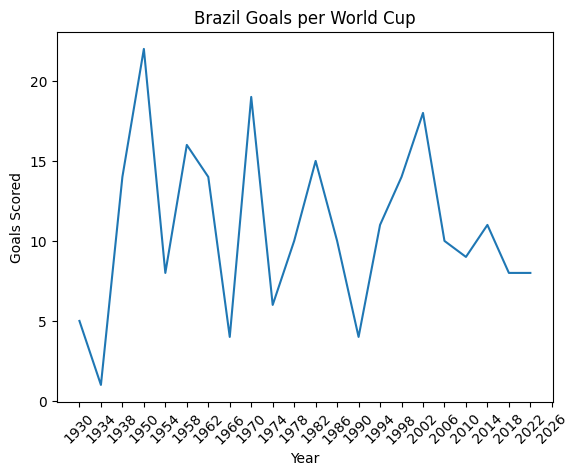

In [20]:
plt.figure()
plt.plot(brazil_wc['Year'], brazil_wc['GF'])
plt.title("Brazil Goals per World Cup")
plt.xlabel("Year")
plt.ylabel("Goals Scored")
plt.xticks(rotation=45)
plt.show()

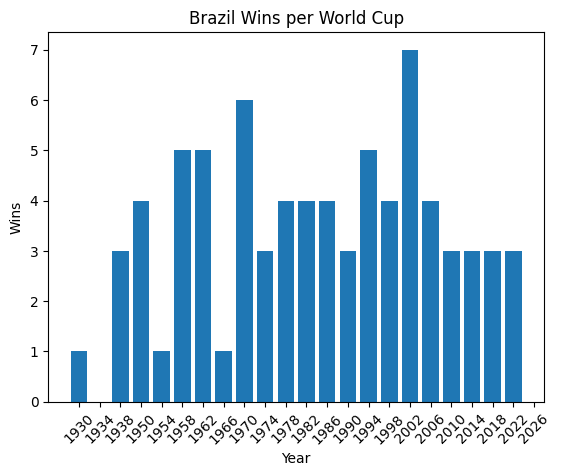

In [21]:
plt.figure()
plt.bar(brazil_wc['Year'], brazil_wc['W'])
plt.title("Brazil Wins per World Cup")
plt.xlabel("Year")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

## Conclusion

Brazil has been the most successful team in FIFA World Cup history, which makes me even more excited for the upcoming tournament.

Key insights:

* High win rate across tournaments
* Multiple championship titles
* Consistently strong attacking performance

This project uses real-world data from the ISLP package and Wikipedia to show how data can be collected, cleaned, and analyzed using Python.


